## Categorical Cross Entropy

<h1> House Number Detection </h1></s>

You have been tasked with building a model that can recognize house numbers from arbitrary street-view images. You are given a set of images of single-digit house numbers engraved into slates or wall surfaces. The images vary in size and color. In this lab, we are going to use the MNIST hand-written digits dataset as a motivating example to understand the __softmax function__, __one-hot encoding__, and __categorical cross-entropy loss__. The MNIST hand-written dataset has 10 classes, each representing a digit from 0-9. We will attempt to build a multi-class classification model that will identify which digit is present in the image. 


In [10]:
from keras.utils import to_categorical
from keras.models import Sequential
import seaborn as sns
from keras.layers import Dense
from sklearn.preprocessing import OneHotEncoder
from keras.losses import CategoricalCrossentropy,SparseCategoricalCrossentropy,BinaryCrossentropy
from sklearn.datasets import make_blobs
from mlxtend.plotting import plot_decision_regions
from urllib.request import urlopen
from PIL import Image
import IPython
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd, numpy as np
from keras.datasets import mnist, fashion_mnist
import random
import tensorflow as tf

In [ ]:
# helper functions for generating synthetic dataset for bpth binary and multi-class
def generate_multiclass_blobs(num_samples_total, training_split, cluster_centers, num_classes, loss_function_used):
    X, targets = make_blobs(n_samples = num_samples_total, centers = cluster_centers, n_features = num_classes, center_box=(0, 1), cluster_std = 1.5)
    categorical_targets = to_categorical(targets)
    X_training = X[training_split:, :]
    X_testing = X[:training_split, :]
    Targets_training = categorical_targets[training_split:]
    Targets_testing = categorical_targets[:training_split].astype(np.int32)
    return X_training, Targets_training, X_testing, Targets_testing


def generate_binary_blobs(num_samples_total, training_split, loss_function_used):
    X, targets = make_blobs(n_samples = num_samples_total, centers = [(0,0), (15,15)], n_features = 2, center_box=(0, 1), cluster_std = 2.5)
    targets[np.where(targets == 0)] = -1
    X_training = X[training_split:, :]
    X_testing = X[:training_split, :]
    Targets_training = targets[training_split:]
    Targets_testing = targets[:training_split]
    return X_training, Targets_training, X_testing, Targets_testing

## Categorical Cross-Entropy

In [8]:
num_samples = 1000
test_split = 250
cluster_centers = [(15,0), (30,15)]
num_classes = len(cluster_centers)
loss_function_used = BinaryCrossentropy(from_logits=True)

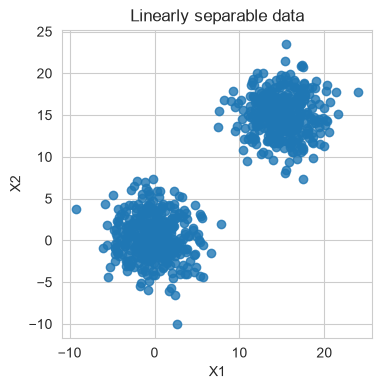

In [13]:
X_training, Targets_training, X_testing, Targets_testing = generate_binary_blobs(num_samples, test_split, loss_function_used)
plt.figure(figsize=(4, 4))
sns.set_style('whitegrid')
plt.scatter(X_training[:,0], X_training[:,1], alpha=0.8)
plt.title('Linearly separable data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

We will build a simple CNN model with two hidden layers, that uses sigmoid as the activation function, and binary cross-entropy as the loss function. Let's define the architecture of our model:

In [14]:
from keras.optimizers import Adam

model = Sequential([
    Dense(12, input_shape=(X_training.shape[1],), activation='relu',
          kernel_initializer='he_uniform'),
    Dense(8, activation='relu', kernel_initializer='he_uniform'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss=loss_function_used,
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

model.fit(X_training, Targets_training, epochs=30, batch_size=5, verbose=1, validation_split=0.2)

c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\backend\tensorflow\ops\nn.py:1553: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4117 - loss: -13.0192 - val_accuracy: 0.1800 - val_loss: -50.9471
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4367 - loss: -310.0065 - val_accuracy: 0.5000 - val_loss: -643.5286
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4433 - loss: -1935.6616 - val_accuracy: 0.5000 - val_loss: -3101.1045
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4500 - loss: -6783.8145 - val_accuracy: 0.5000 - val_loss: -9194.7207
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4550 - loss: -16721.5820 - val_accuracy: 0.4867 - val_loss: -20342.7598
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4600 - loss: -33242.8086 - val_accuracy: 0.5000 - val_loss: -37717.7266
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4633 - loss: -57549.6602 - val_accuracy: 0.5000 - val_loss: -62238.8320
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accu

## Evaluate Metrics

In [16]:
test_score = model.evaluate(X_testing, Targets_testing, verbose=1)

print(f"Test Results - Loss: {test_score[0]:.3f}  |  Accuracy: {test_score[1]:.3f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5600 - loss: -3405659.2500 
Test Results - Loss: -3405659.250  |  Accuracy: 0.560


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

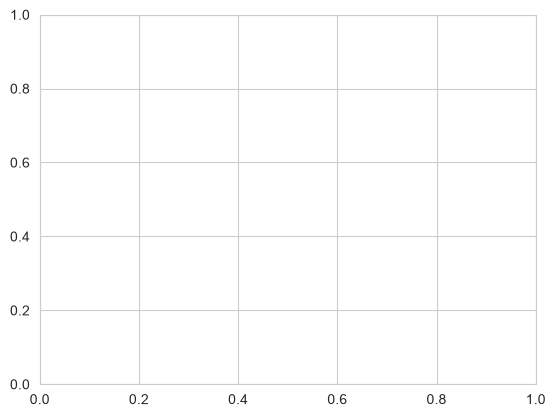

In [21]:
plot_decision_regions(X_testing, Targets_testing, clf=model, legend=2)
plt.figure(figsize=(4, 4))
plt.show()

## Multi-class Classification

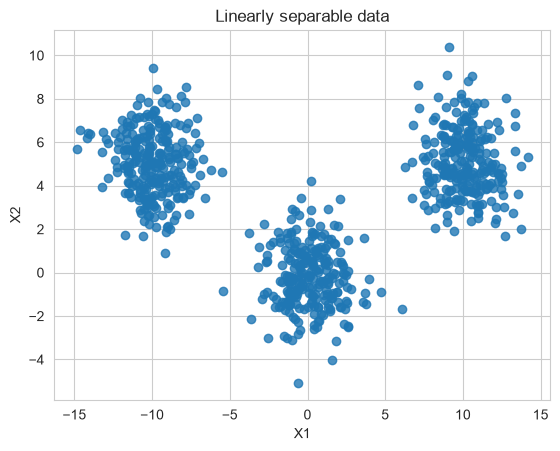

In [30]:
# parameters
num_samples = 1000
train_split = 250
cluster_centers = [(-10, 5), (0, 0), (10, 5)]
num_classes = len(cluster_centers)
loss_function_used = CategoricalCrossentropy(from_logits=True)

X_training, Targets_training, X_testing, Targets_testing= generate_multiclass_blobs(num_samples, train_split,
              cluster_centers, num_classes,
              loss_function_used)

plt.scatter(X_training[:,0], X_training[:,1], alpha=0.8)
plt.title('Linearly separable data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [31]:
feature_vector_shape = X_training.shape[1]
input_shape = (feature_vector_shape,)

model = Sequential()
model.add(Dense(12, input_shape=input_shape, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(8, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(num_classes, activation='softmax'))
model.compile(loss=loss_function_used, optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
history = model.fit(X_training, Targets_training, epochs=30, batch_size=5, verbose=1, validation_split=0.2)
test_score = model.evaluate(X_testing, Targets_testing, verbose=1)

print(f"Test Results - Loss: {test_score[0]:.3f}  |  Accuracy: {test_score[1]:.3f}")

c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\backend\tensorflow\ops\nn.py:1436: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5983 - loss: 1.1490 - val_accuracy: 0.7067 - val_loss: 0.6825
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7983 - loss: 0.4645 - val_accuracy: 0.8533 - val_loss: 0.3128
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9117 - loss: 0.2378 - val_accuracy: 0.9067 - val_loss: 0.2073
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9500 - loss: 0.1513 - val_accuracy: 0.9467 - val_loss: 0.1319
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9733 - loss: 0.1029 - val_accuracy: 0.9733 - val_loss: 0.0911
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.0727 - val_accuracy: 0.9867 - val_loss: 0.0645
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0531 - val_accuracy: 1.0000 - val_loss: 0.0476
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9933 - loss: 0.0398 - val_accuracy: 1.0000 - val_